# 00 · Exact model, completion and target interfaces

This notebook is an executable guide to the paper's mathematical objects, using **hand-constructed finite response tables**. It does not read native experimental data, generate new battle measurements, or count these examples toward the paper's empirical denominators. Run every cell in order to verify the assertions below.

Reading path: finite response table → support core at a fixed frontier → branches for above-frontier conflicts → helper repair → target-antichain queries. Completion here permits the joint publication of multiple items, imposes no batch-size limit, and does not model each intermediate publication step.

In [1]:
from pathlib import Path
import os
import sys

# Run from the repository root or notebooks/; an explicit WOWFS_SOURCE_ROOT is also supported.
candidates = ([Path(os.environ["WOWFS_SOURCE_ROOT"])]
              if os.environ.get("WOWFS_SOURCE_ROOT") else [])
candidates += [Path.cwd(), *Path.cwd().parents]
ROOT = next((path.resolve() for path in candidates
             if (path / "pyproject.toml").is_file()
             and (path / "src/wowfs").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Run from this repository or set WOWFS_SOURCE_ROOT")
sys.path.insert(0, str(ROOT / "src"))
sys.dont_write_bytecode = True  # Keep the source directory clean; display figures inline only.
from wowfs.paths import setup_paths
setup_paths()

from dataclasses import replace
from fractions import Fraction as F
from itertools import combinations
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from wowfs.experiments import co_exact, co_reference, mi_theory

# Public inputs use the rational Model, which rejects floats; reference only adapts the algorithms.
def as_reference(model):
    return co_reference.Model(
        dict(model.slots),
        tuple(co_reference.Configuration(row.support, row.values)
              for row in model.configurations),
        model.weights, model.tolerance, model.required_mass)

print("Exact rational arithmetic; synthetic examples only")

Exact rational arithmetic; synthetic examples only


## Support at a fixed frontier

Each configuration consists of one item from the left slot and one from the right slot. Its task responses are fixed by the table; after an item set is selected, every available configuration contributes to each task's maximum. Each selected item must remain close to the frontier on sufficient task weight, and **helpers bear the same retention obligations**.

The example has two tasks, each with weight $1/2$, required retention mass $1$, zero tolerance, and a fixed comparison frontier of $(10,10)$. The four-cycle `a,b,u,v` supports itself; a separate path with alternating task support loses support progressively from its endpoints, and the isolated item is also removed. All responses are at or below the fixed frontier, so support deletion operates in a safe domain.

In [2]:
slots = {name: 0 for name in ("a", "b", "c", "d", "isolated")}
slots |= {name: 1 for name in ("u", "v", "w", "z")}
response_rows = [
    ("a", "u", (10, 0)), ("a", "v", (0, 10)),
    ("b", "u", (0, 10)), ("b", "v", (10, 0)),
    ("c", "w", (10, 0)), ("d", "w", (0, 10)), ("d", "z", (10, 0)),
]
model = co_exact.Model(
    slots, tuple(co_exact.Configuration({left, right}, values)
                 for left, right, values in response_rows),
    (F(1, 2), F(1, 2)), (0, 0), 1, {"a", "u"}, (10, 10), (1, 1), F(1, 2))
reference, level = as_reference(model), (10, 10)
core, deletion_trace = co_reference.support_core(reference, model.items, level)
synchronous_core, deletion_rounds = co_reference.core_slow(reference, model.items, level)
assert core == synchronous_core == frozenset({"a", "b", "u", "v"})
assert co_exact.evaluate(model, core, fixed_y=level)["valid"]
display(pd.DataFrame(response_rows, columns=["left", "right", "task_responses"]))
display(pd.DataFrame(deletion_trace))
print("Greatest support core:", sorted(core))
print("Synchronous deletion rounds:", deletion_rounds)

,left,right,task_responses
0,a,u,"(10, 0)"
1,a,v,"(0, 10)"
2,b,u,"(0, 10)"
3,b,v,"(10, 0)"
4,c,w,"(10, 0)"
5,d,w,"(0, 10)"
6,d,z,"(10, 0)"


,item,available_task_mass
0,c,1/2
1,isolated,0
2,z,1/2
3,w,1/2
4,d,0


Greatest support core: ['a', 'b', 'u', 'v']
Synchronous deletion rounds: [['c', 'isolated', 'z'], ['d', 'w']]


## Support does not ensure safety

The support core checks retention at a given frontier. If an available configuration exceeds the frontier, item combinations that activate it must first be excluded; the support core is then computed within each safe branch.

Below, two optional pairs, `x1–y1` and `x2–y2`, have response 15, above the target frontier of 12. All other new configurations have response 12, the historical configuration has response 10, and the tolerance is 2. The two independent conflicts yield four maximal completions. Requiring `x1` as a target forbids `y1`; requiring both makes completion infeasible.

In [3]:
left, right = ("old", "x1", "x2"), ("base", "y1", "y2")
conflict_pairs = {frozenset({"x1", "y1"}), frozenset({"x2", "y2"})}
conflict_rows = tuple(co_exact.Configuration(
    {a, b}, (15 if frozenset({a, b}) in conflict_pairs
             else 10 if (a, b) == ("old", "base") else 12,))
    for a in left for b in right)
conflict_model = co_exact.Model(
    {item: 0 for item in left} | {item: 1 for item in right}, conflict_rows,
    (1,), (2,), 1, {"old", "base"}, (12,), (2,), 1)
conflict_reference = as_reference(conflict_model)
branch_answer = co_reference.fixed_frontier(
    conflict_reference, conflict_model.history, (12,), all_branches=True)
truth = co_exact.exhaustive(conflict_model, fixed_y=(12,), all_solutions=True)
assert branch_answer["cover_size"] == 2
assert len(branch_answer["kernels"]) == 4
assert set(branch_answer["kernels"]) == {frozenset(k) for k in truth["kernels"]}
forced = co_reference.fixed_frontier(
    conflict_reference, conflict_model.history | {"x1"}, (12,), all_branches=True)
blocked = co_reference.fixed_frontier(
    conflict_reference, conflict_model.history | {"x1", "y1"}, (12,))
assert forced["unary_forbidden"] == {"y1"}
assert not blocked["feasible"] and blocked["reason"] == "mandatory_above_frontier"
display(pd.DataFrame({"maximal_completion": [sorted(k) for k in branch_answer["kernels"]]}))
print("Cover size:", branch_answer["cover_size"], "; branches:", branch_answer["branches"])
print("Mandatory conflicting pair:", blocked["reason"])

,maximal_completion
0,"[base, old, y1, y2]"
1,"[base, old, x1, y2]"
2,"[base, old, x2, y1]"
3,"[base, old, x1, x2]"


Cover size: 2 ; branches: 4
Mandatory conflicting pair: mandatory_above_frontier


## Latent helper repair: same current frontier, different future answers

This example uses the paper's existing exact construction, `latent_repair_instance`. The current frontier after the first update is the same for `good` and `bad`; the future `repair` item can repair the `good` history, but exceeds the cap when combined with `bad`.

The table below queries the same target, `c0`. A `YES` answer must include a joint-publication witness that an independent verifier can check; a `NO` answer is also cross-checked by exhaustive subset enumeration. This establishes only the future completability of these two specified histories and must not be interpreted as native class performance.

In [4]:
latent, initial_history, _ = co_reference.latent_repair_instance(2)
helper_answers = []
current_frontiers = []
for first in ("good", "bad"):
    candidate = co_exact.Model(
        latent.slots,
        tuple(co_exact.Configuration(row.support, row.values) for row in latent.configurations),
        latent.weights, latent.tolerance, latent.required_mass,
        initial_history | {first}, (F(103, 100),) * 2,
        (F(1, 100),) * 2, F(1, 2))
    current_frontiers.append(co_exact.frontier(candidate, candidate.history))
    answer = co_reference.solve(candidate, D={"c0"})
    oracle = co_exact.exhaustive(candidate, D={"c0"})
    assert answer["status"] == oracle["status"] == ("YES" if first == "good" else "NO")
    if answer["status"] == "YES":
        assert "repair" in answer["items"]
        assert co_exact.evaluate(candidate, answer["items"])["valid"]
    helper_answers.append({"first_update": first,
        "current_frontier": tuple(map(str, current_frontiers[-1])),
        "target": "c0", "answer": answer["status"],
        "verified_publication": answer.get("items")})
assert current_frontiers[0] == current_frontiers[1]
display(pd.DataFrame(helper_answers))

,first_update,current_frontier,target,answer,verified_publication
0,good,"(51/50, 1)",c0,YES,"[base, c0, good, old, repair]"
1,bad,"(51/50, 1)",c0,NO,None


## Third-order obstruction and target antichain: every pair is possible, the triple is not

Let the targets be $x_0,x_1,x_2$. The allowed family contains the empty set, all three singletons, and all three pairs, excluding only the triple. The existing universal construction realizes this downward-closed family as an explicit two-slot **synthetic response table**: each selector corresponds to a maximal target set, and table entries are 100, 102, or 104.

Full completions retain helper and selector details. Intersect them with the target universe and remove projections contained in another projection to obtain the target antichain. A query $D$ asks whether any antichain member contains $D$. This preserves answers to the specified target queries, but not helper identities, minimum costs, or batch-size constraints.

In [5]:
n, allowed_family = 3, frozenset(range(7))  # Bitmask 111 = 7 is the only excluded query.
table, selectors = mi_theory.construction(n, allowed_family)
gloves = ["old", "helper"] + [f"x{i}" for i in range(n)]
boots = ["base"] + [f"selector_{mask:03b}" for mask in selectors]
targets = frozenset(gloves[2:])
universal_model = co_exact.Model(
    {item: 0 for item in gloves} | {item: 1 for item in boots},
    tuple(co_exact.Configuration({glove, boot}, (F(table[g][b], mi_theory.SCALE),))
          for g, glove in enumerate(gloves) for b, boot in enumerate(boots)),
    (1,), (1,), 1, {"old", "base"}, (110,), (1,), 1)
interface = co_reference.compile_interface(universal_model)
assert interface["complete"]
assert mi_theory.exact_family(table)[0] == mi_theory.brute_family(table) == allowed_family
projections = {frozenset(k) & targets for k in interface["kernels"]}
antichain = sorted((p for p in projections if not any(p < other for other in projections)),
                   key=lambda p: tuple(sorted(p)))
query_rows = []
for mask in range(1 << n):
    query = frozenset(f"x{i}" for i in range(n) if mask >> i & 1)
    answer = co_exact.interface_query(interface, query)["status"]
    from_antichain = any(query <= member for member in antichain)
    assert (answer == "YES") == from_antichain == (mask in allowed_family)
    query_rows.append({"mask": f"{mask:03b}", "target_set": ", ".join(sorted(query)) or "∅",
                       "cardinality": len(query), "answer": answer})
queries = pd.DataFrame(query_rows)
assert set(queries.loc[queries.cardinality == 2, "answer"]) == {"YES"}
assert queries.loc[queries.cardinality == 3, "answer"].tolist() == ["NO"]
display(pd.DataFrame([[str(F(value, mi_theory.SCALE)) for value in row] for row in table],
                     index=gloves, columns=boots))
display(pd.DataFrame({"maximal_target_set": [sorted(p) for p in antichain]}))
display(queries)

,base,selector_011,selector_101,selector_110
old,100,102,102,102
helper,102,102,102,102
x0,102,102,102,104
x1,102,102,104,102
x2,102,104,102,102


,maximal_target_set
0,"[x0, x1]"
1,"[x0, x2]"
2,"[x1, x2]"


,mask,target_set,cardinality,answer
0,000,∅,0,YES
1,001,x0,1,YES
2,010,x1,1,YES
3,011,"x0, x1",2,YES
4,100,x2,1,YES
5,101,"x0, x2",2,YES
6,110,"x1, x2",2,YES
7,111,"x0, x1, x2",3,NO


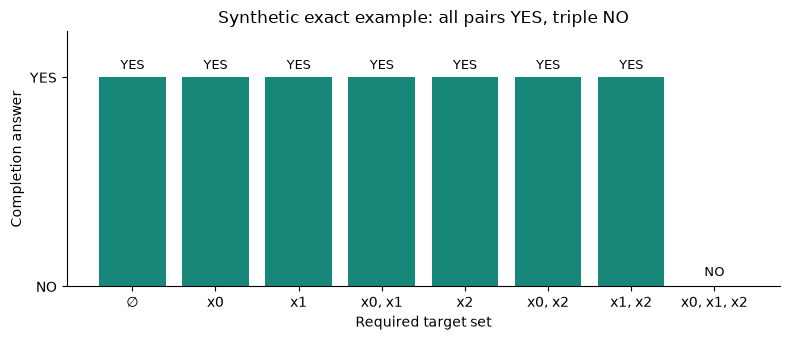

In [6]:
# The figure displays only the query language; the exact API above computes responses and decisions.
fig, ax = plt.subplots(figsize=(8, 3.5))
values = queries["answer"].eq("YES").astype(int)
colors = ["#168779" if answer == "YES" else "#b65d53" for answer in queries["answer"]]
ax.bar(queries["target_set"], values, color=colors)
for index, answer in enumerate(queries["answer"]):
    ax.text(index, 1.04 if answer == "YES" else 0.05, answer, ha="center", fontsize=9)
ax.set(ylim=(0, 1.22), yticks=[0, 1], yticklabels=["NO", "YES"],
       xlabel="Required target set", ylabel="Completion answer",
       title="Synthetic exact example: all pairs YES, triple NO")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## What was checked

The response tables, thresholds, and queries are shown in full. All decisions use the repository's existing exact algorithms and are cross-checked by synchronous deletion, exhaustive subset enumeration, or an independent family oracle. The figure is a teaching example and does not replace the paper's native figures or tables.

More extensive tests of deletion order, greatest fixed points, and representation consistency are in `tests/test_reproducible_core.py`. Subsequent notebooks and the paper asset map document the paper's figures, tables, and data sources. Run reproduction in a directory under `WOWFS_WORK_ROOT`, then copy successful executed notebooks into `notebooks/` and commit them with their outputs so figures and tables remain visible on GitHub.